In [1]:
import QuantLib as ql
import numpy as np

In [2]:
today = ql.Date(7, ql.March, 2014)
ql.Settings.instance().evaluationDate = today

<h2>The Instrument</h2>

An example of European Option

In [3]:
option = ql.EuropeanOption(ql.PlainVanillaPayoff(ql.Option.Call, 100.0),
                           ql.EuropeanExercise(ql.Date(7, ql.June, 2014)))    


<h3>First pricing method: analytic Black-Scholes formula</h3>

Using analytic Black-Scholes formula.

In [4]:
u = ql.SimpleQuote(100.0)
r = ql.SimpleQuote(0.01)
sigma = ql.SimpleQuote(.20)

In [5]:
riskFreeCurve = ql.FlatForward(0, ql.TARGET(),
ql.QuoteHandle(r), ql.Actual360())
volatility = ql.BlackConstantVol(0, ql.TARGET(),
ql.QuoteHandle(sigma), ql.Actual360())

Instantiate the Black Scholes process

In [6]:
process = ql.BlackScholesProcess(ql.QuoteHandle(u),
                                 ql.YieldTermStructureHandle(riskFreeCurve),
                                 ql.BlackVolTermStructureHandle(volatility))

Once we have the process, we can finally use it to build the engine…

In [7]:
engine = ql.AnalyticEuropeanEngine(process)

…and once we have the engine, we can set it to the option and evaluate the latter.

In [8]:
option.setPricingEngine(engine)

In [9]:
print(option.NPV())

4.155543462156206


Greeks now

In [10]:
print(option.delta())
print(option.gamma())
print(option.vega())

0.5302223303784392
0.03934493301271913
20.109632428723106


<h4>Market Changes</h4>

market data are stored in Quote instances and thus can notify the option when any
of them changes.

In [11]:
u.setValue(105.0)
print(option.NPV())

7.27556357927846


In [12]:
xs = np.linspace(80.0, 120.0, 400)
x = []
y = []
for v in xs:
    x.append(v)
    u.setValue(v)
    y.append(option.NPV())
    
print(len(y))

400


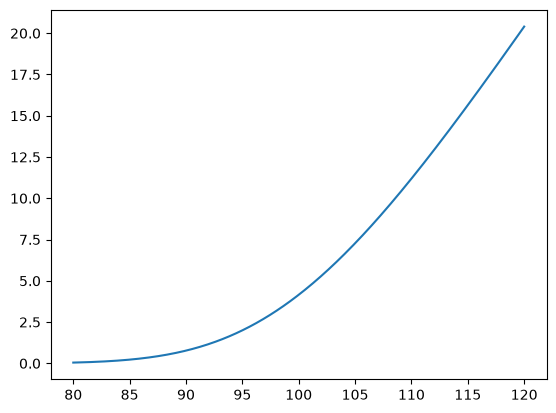

In [13]:
%matplotlib inline

import matplotlib.pyplot as plt

plt.plot(x,y)
plt.show()


Other market data also affect the value, of course.

In [14]:
u.setValue(105.0)
r.setValue(0.01)
sigma.setValue(0.20)

In [15]:
print(option.NPV())

7.27556357927846


We can see it when we change the risk-free rate…

In [16]:
r.setValue(0.03)

In [17]:
print(option.NPV())

7.624029148527754


…or the volatility.

In [18]:
sigma.setValue(0.25)

In [19]:
print(option.NPV())

8.531296969971573


<h4>Date changes</h4>

the value also changes if we advance the evaluation date.

In [20]:
u.setValue(105.0)
r.setValue(0.01)
sigma.setValue(0.20)

In [21]:
print(option.NPV())

7.27556357927846


…and then move to a date two months before exercise.

In [22]:
ql.Settings.instance().evaluationDate = ql.Date(7, ql.April, 2014)

In [23]:
print(option.NPV())

6.560073820974377


In [24]:
ys = []
for x in xs:
    u.setValue(x)
    ys.append(option.NPV())
ax.plot


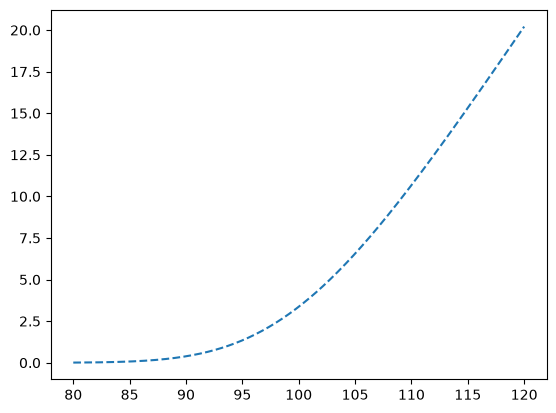

In [25]:
%matplotlib inline

import matplotlib.pyplot as plt

plt.plot(x,y,'--')
plt.show()


In the default library configuration, the returned value goes down to 0 when we reach the exercise
date.

In [26]:
ql.Settings.instance().evaluationDate = ql.Date(7, ql.June, 2014)

In [27]:
print(option.NPV())

0.0


<h3>Other pricing methods</h3>

Reset the data first

In [28]:
today = ql.Date(7, ql.March, 2014)
ql.Settings.instance.evaluationDate= today
u.setValue(105.0)
r.setValue(0.01)
sigma.setValue(0.20)

In [29]:
print(option.NPV())

0.0


Let’s say that we want to use a Heston model to price the option.

In [30]:
model= ql.HestonModel(
    ql.HestonProcess(
        ql.YieldTermStructureHandle(riskFreeCurve),
        ql.YieldTermStructureHandle(ql.FlatForward(0, ql.TARGET(),
                                                  0.0, ql.Actual360())),
        ql.QuoteHandle(u),
        0.04, 0.1, 0.01, 0.05, -0.75))


In [31]:
engine = ql.AnalyticHestonEngine(model)
option.setPricingEngine(engine)

In [32]:
print(option.NPV())

0.0
